# Video Segmentation with Multiple Bounding Boxes in SAM3

This notebook demonstrates how to use bounding boxes for video segmentation in SAM3/SAM3.1.

**Main Use Case**: Track multiple objects (2+) with their own bounding boxes and propagate across the entire video.

## Setup

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os

device = torch.device("cuda")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

In [2]:
import sam3

from sam3.model_builder import build_sam3_video_model
from sam3.visualization_utils import show_box, show_mask


# Build SAM3 model
sam3_model = build_sam3_video_model()
predictor = sam3_model.tracker
predictor.backbone = sam3_model.detector.backbone

# Get path to video
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")
video_path = f"{sam3_root}/assets/videos/bedroom.mp4"

print(f"Loading video from: {video_path}")

/cluster/scratch/niacobone/sam3/myenv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-05-22 19:41:34,281 3752795 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


Loading video from: /cluster/scratch/niacobone/sam3/sam3/../assets/videos/bedroom.mp4


In [3]:
# Load video frames for visualization
cap = cv2.VideoCapture(video_path)
video_frames_for_vis = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

frame0 = video_frames_for_vis[0]
width, height = frame0.shape[1], frame0.shape[0]
print(f"Video resolution: {width}x{height}, Total frames: {len(video_frames_for_vis)}")

Video resolution: 960x540, Total frames: 200


## Track 2 Objects with Bounding Boxes and Propagate Through Video

This is the primary way to use multiple bounding boxes in SAM3 - provide one box per object and track them across the entire video.

In [4]:
# Initialize inference state
inference_state = predictor.init_state(video_path=video_path)

# Clear any previous prompts
predictor.clear_all_points_in_video(inference_state)

print("Inference state initialized and ready for prompts.")

Inference state initialized and ready for prompts.


In [5]:
# Step 1: Define bounding boxes for two objects on frame 0
ann_frame_idx = 0  # Initial frame where we provide prompts

# Object 1: Child on the right
obj_id_1 = 1
box_1 = np.array([300, 0, 500, 400], dtype=np.float32)  # pixel coordinates: (x_min, y_min, x_max, y_max)
rel_box_1 = np.array([[box_1[0] / width, box_1[1] / height, box_1[2] / width, box_1[3] / height]], dtype=np.float32)

# Object 2: Child on the left
obj_id_2 = 2
box_2 = np.array([100, 200, 250, 500], dtype=np.float32)  # pixel coordinates: (x_min, y_min, x_max, y_max)
rel_box_2 = np.array([[box_2[0] / width, box_2[1] / height, box_2[2] / width, box_2[3] / height]], dtype=np.float32)

print(f"Object 1 (ID={obj_id_1}): Box in pixels: {box_1}")
print(f"Object 2 (ID={obj_id_2}): Box in pixels: {box_2}")

Object 1 (ID=1): Box in pixels: [300.   0. 500. 400.]
Object 2 (ID=2): Box in pixels: [100. 200. 250. 500.]


In [6]:
# Step 2: Add prompts for both objects on frame 0
print(f"Adding prompts for 2 objects on frame {ann_frame_idx}...")

# Add first object's box
_, out_obj_ids_1, _, video_res_masks_1 = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=obj_id_1,
    box=rel_box_1,
)

# Add second object's box
_, out_obj_ids, _, video_res_masks = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=obj_id_2,
    box=rel_box_2,
)

print(f"Added prompts. Tracked objects: {out_obj_ids}")

Adding prompts for 2 objects on frame 0...
Added prompts. Tracked objects: [1, 2]


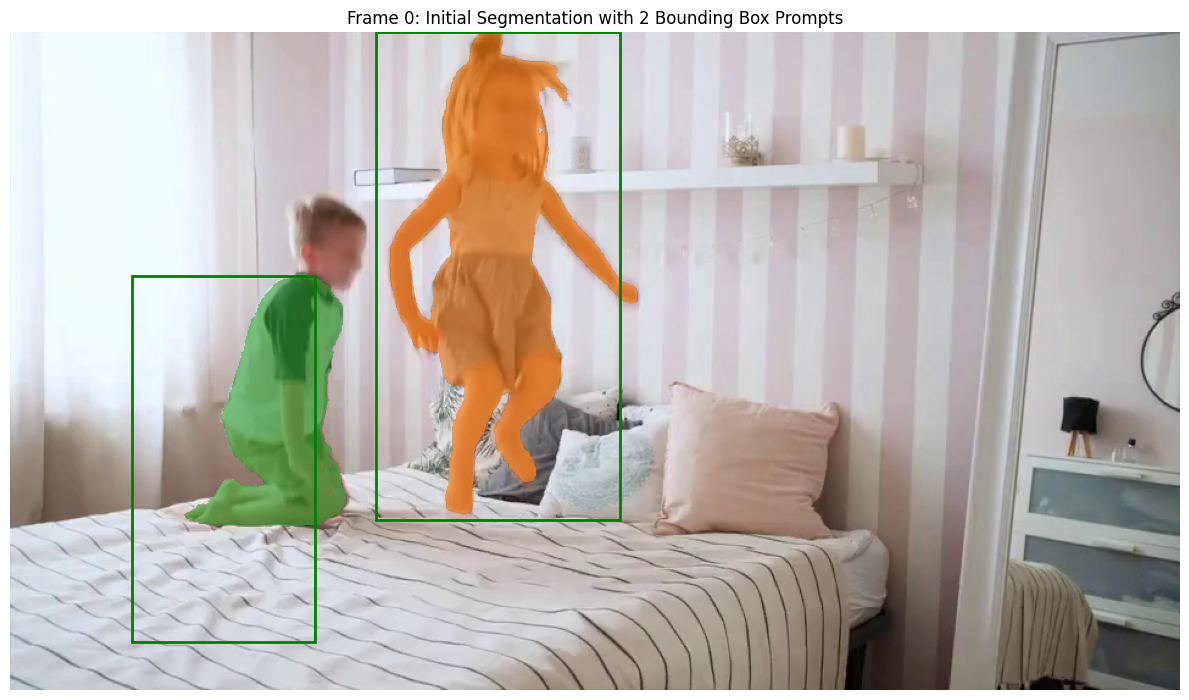

Object 1: Green segmentation mask
Object 2: Orange segmentation mask


In [7]:
# Step 3: Visualize the prompts and initial segmentations on frame 0
plt.figure(figsize=(12, 8))
plt.imshow(video_frames_for_vis[ann_frame_idx])

# Draw boxes
show_box(box_1, plt.gca())
show_box(box_2, plt.gca())

# Draw segmentation masks for all objects
for i, obj_id in enumerate(out_obj_ids):
    show_mask((video_res_masks[i] > 0.0).cpu().numpy(), plt.gca(), obj_id=obj_id)

plt.title(f"Frame {ann_frame_idx}: Initial Segmentation with 2 Bounding Box Prompts")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Object {obj_id_1}: Green segmentation mask")
print(f"Object {obj_id_2}: Orange segmentation mask")

In [8]:
# Step 4: Propagate prompts through the entire video
print("\nPropagating prompts through the entire video...")
print("This tracks both objects across all frames.\n")

video_segments = {}  # Store results for all frames

for frame_idx, obj_ids, low_res_masks, video_res_masks, obj_scores in predictor.propagate_in_video(
    inference_state, 
    start_frame_idx=ann_frame_idx,
    max_frame_num_to_track=len(video_frames_for_vis),  # Track all frames
    reverse=False,
    propagate_preflight=True
):
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

print(f"✓ Propagation complete. Segmented {len(video_segments)} frames with {len(out_obj_ids)} objects.")


Propagating prompts through the entire video...
This tracks both objects across all frames.



propagate in video:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Propagation complete. Segmented 200 frames with 2 objects.


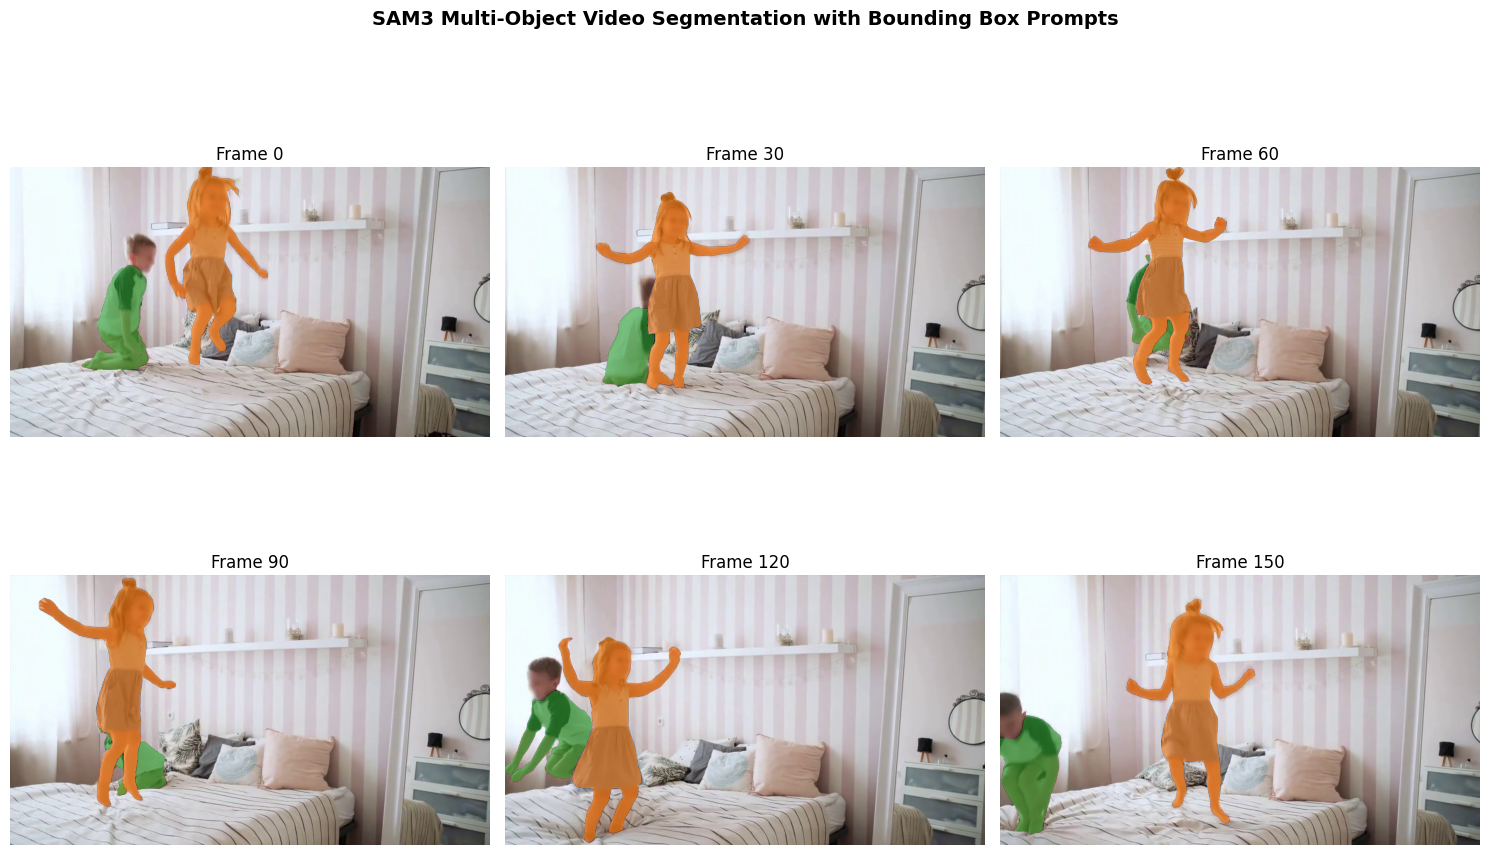


Showing frames: [0, 30, 60, 90, 120, 150]
Stride: 30 frames


In [9]:
# Step 5: Visualize tracking results every N frames
vis_frame_stride = 30
frame_indices = list(range(0, len(video_frames_for_vis), vis_frame_stride))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for plot_idx, frame_idx in enumerate(frame_indices):
    ax = axes[plot_idx]
    ax.imshow(video_frames_for_vis[frame_idx])
    
    # Draw segmentation masks for this frame
    if frame_idx in video_segments:
        for out_obj_id, out_mask in video_segments[frame_idx].items():
            show_mask(out_mask, ax, obj_id=out_obj_id)
    
    ax.set_title(f"Frame {frame_idx}")
    ax.axis('off')

plt.suptitle("SAM3 Multi-Object Video Segmentation with Bounding Box Prompts", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nShowing frames: {frame_indices}")
print(f"Stride: {vis_frame_stride} frames")

In [10]:
# Step 6: Summary statistics
print("\n" + "="*60)
print("TRACKING SUMMARY")
print("="*60)

for obj_id in out_obj_ids:
    frames_with_object = sum(1 for frame_idx in video_segments if obj_id in video_segments[frame_idx])
    print(f"Object {obj_id}:")
    print(f"  - Tracked in {frames_with_object}/{len(video_segments)} frames")
    
    # Calculate mask sizes
    mask_sizes = []
    for frame_idx in video_segments:
        if obj_id in video_segments[frame_idx]:
            mask = video_segments[frame_idx][obj_id]
            mask_sizes.append(np.sum(mask))
    
    if mask_sizes:
        avg_size = np.mean(mask_sizes)
        print(f"  - Average mask size: {avg_size:.0f} pixels")

print("\nTracking completed successfully!")
print("="*60)


TRACKING SUMMARY
Object 1:
  - Tracked in 200/200 frames
  - Average mask size: 33652 pixels
Object 2:
  - Tracked in 200/200 frames
  - Average mask size: 16335 pixels

Tracking completed successfully!


## API Reference: Using Multiple Bounding Boxes

### Key Function: `add_new_points_or_box()`

```python
predictor.add_new_points_or_box(
    inference_state=inference_state,  # State from init_state()
    frame_idx=0,                      # Frame to add prompt on
    obj_id=1,                         # Unique ID for this object
    box=rel_box,                      # Box as [x_min, y_min, x_max, y_max] in [0,1]
)
```

### Workflow: 3 Steps

1. **Initialize State**
   ```python
   inference_state = predictor.init_state(video_path=video_path)
   ```

2. **Add Box Prompts for Each Object**
   ```python
   # Object 1
   predictor.add_new_points_or_box(
       inference_state=inference_state,
       frame_idx=0,
       obj_id=1,
       box=rel_box_1,
   )
   
   # Object 2
   predictor.add_new_points_or_box(
       inference_state=inference_state,
       frame_idx=0,
       obj_id=2,
       box=rel_box_2,
   )
   ```

3. **Propagate Through Video**
   ```python
   for frame_idx, obj_ids, _, video_res_masks, _ in predictor.propagate_in_video(
       inference_state,
       start_frame_idx=0,
       max_frame_num_to_track=len(video_frames),
       reverse=False,
   ):
       # Process results for each frame
       pass
   ```

### Important Notes

- **One box per object**: Each object gets exactly one bounding box (cannot pass multiple boxes for single object)
- **Unique IDs**: Each object must have a unique `obj_id` (any integer)
- **Normalized coordinates**: Box must be in range [0, 1]
  - Convert from pixels: `rel_box = [x_min/width, y_min/height, x_max/width, y_max/height]`
- **Call order**: Add prompts for all objects before calling `propagate_in_video()`
- **Propagation direction**: 
  - `reverse=False` for forward tracking
  - `reverse=True` for backward tracking

## Optional: Comparing Multiple Box Proposals for One Object

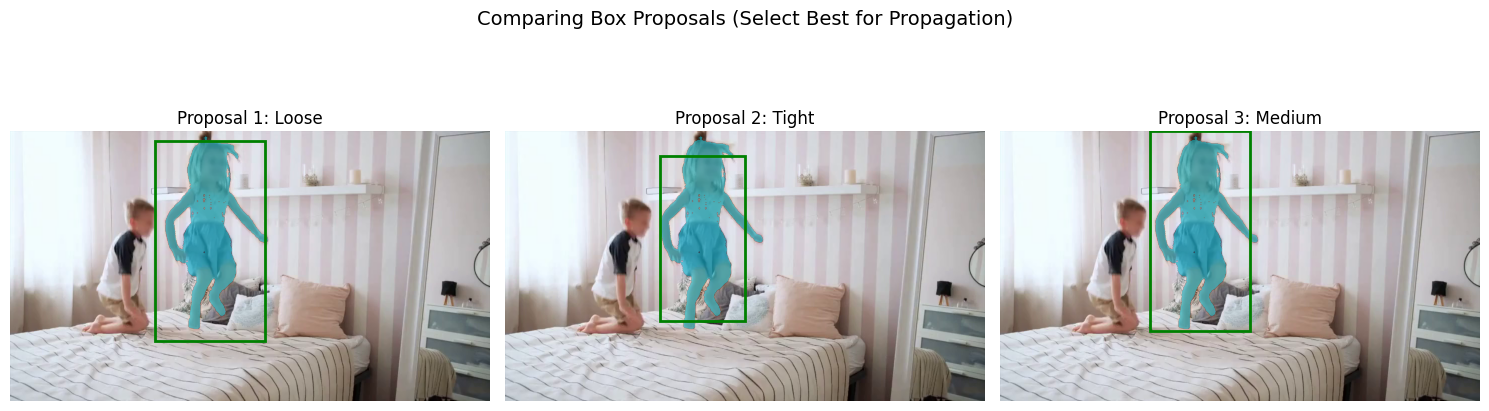

In [11]:
# Use different obj_ids to compare multiple box proposals
inference_state = predictor.init_state(video_path=video_path)
predictor.clear_all_points_in_video(inference_state)

ann_frame_idx = 0

# Multiple proposals for the same object (e.g., from different detectors)
box_proposals = [
    {"proposal_id": 1, "box": [290, 20, 510, 420], "label": "Loose"},
    {"proposal_id": 2, "box": [310, 50, 480, 380], "label": "Tight"},
    {"proposal_id": 3, "box": [300, 0, 500, 400], "label": "Medium"},
]

proposal_masks = {}

for proposal in box_proposals:
    proposal_id = proposal["proposal_id"]
    box = np.array([proposal["box"]], dtype=np.float32)
    rel_box = np.array([[box[0, 0] / width, box[0, 1] / height, 
                         box[0, 2] / width, box[0, 3] / height]], dtype=np.float32)
    
    _, out_obj_ids, _, video_res_masks = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=100 + proposal_id,
        box=rel_box,
    )
    
    proposal_masks[proposal_id] = {
        "mask": (video_res_masks[0] > 0.0).cpu().numpy(),
        "label": proposal["label"],
        "box": box[0],
    }

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (proposal_id, data) in enumerate(proposal_masks.items()):
    ax = axes[idx]
    ax.imshow(video_frames_for_vis[ann_frame_idx])
    show_box(data["box"], ax)
    show_mask(data["mask"], ax, obj_id=100 + proposal_id)
    ax.set_title(f"Proposal {proposal_id}: {data['label']}")
    ax.axis('off')

plt.suptitle("Comparing Box Proposals (Select Best for Propagation)", fontsize=14)
plt.tight_layout()
plt.show()